In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../..')

from sn_clf.scripts.utils import get_sn_label_from_akb, load_features, download_akb_json, plot_config

plot_config()

In [2]:
#Crossmatch ojects from BTS and OIDs file
oids, features = load_features('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/feature_snad_clf_r_100.dat')

#t = time.monotonic()
#bts_oids = list(bts_sn['OID'])
#crossmatch = np.isin(oids, bts_oids)
#print(f'Crossmatched in {np.round((time.monotonic() - t) / 60)} min')
#np.save(f'../data/bts_dr23_crossmatch.npy', crossmatch)

crossmatch = np.load(f'../data/bts_dr23_crossmatch.npy')

In [3]:
#download_akb_json('akb_objects.json')
akb_oids, akb_sn_label = get_sn_label_from_akb('../data/akb_objects.json')

In [4]:
akb_oid_sn = akb_oids[akb_sn_label == 1]
#akb_crossmatch = np.isin(oids, akb_oid_sn)

In [5]:
#np.save(f'../data/akb_sn_dr23_crossmatch.npy', akb_crossmatch)
akb_crossmatch = np.load(f'../data/akb_sn_dr23_crossmatch.npy')

In [6]:
model_name = 'SNclf_bts'
random_seed = 42
#Choose features, which will be used in training process
feature_names = '../../dr23-features/feature_snad_clf_r_100.name'
with open(feature_names) as f:
    names = f.read().split()

# тут в качестве негативного класса используются рандомные объекты из дата релиза
bts_features = features[crossmatch] # содержит только SN
akb_sn_features = features[akb_crossmatch]

indx = np.random.choice(np.arange(len(oids)), len(bts_features)+len(akb_sn_features))
regular_obj = features[indx]
train_data = np.vstack([bts_features, regular_obj[:len(bts_features)]])
test_data = np.vstack([akb_sn_features, regular_obj[len(bts_features):]])

train_labels = np.hstack([np.ones(len(bts_features)), np.zeros(len(bts_features))])
test_labels = np.hstack([np.ones(len(akb_sn_features)), np.zeros(len(akb_sn_features))])

In [13]:
oids[indx]

array([591204100011441, 486201200038788, 540211300007548, ...,
       282208300119139, 487207100080997, 486215100003705],
      shape=(2950,), dtype=uint64)

In [12]:
# Train and validate real-bogus model
print('Training model...')
t = time.monotonic()
model = RandomForestClassifier(max_depth=18, n_estimators=831, random_state=random_seed)
score_types = ('accuracy', 'roc_auc', 'f1')

result = cross_validate(model, train_data, train_labels,
                        cv=KFold(shuffle=True, random_state=random_seed),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                        n_jobs=5
                       )

print('Scores for Random Forest Classifier:')
for score in score_types:
    mean = np.mean(result[f'test_{score}'])
    std = np.std(result[f'test_{score}'])
    print(f'{score} = {mean:.3f} +- {std:.3f}')
t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')
    
#assert np.mean(result['test_accuracy']) > 0.7, 'Accuracy for trained model is too low!'
clf = result['estimator'][0]

#convert_to_onnx(clf, len(names), name=model_name)

Training model...
Scores for Random Forest Classifier:
accuracy = 0.954 +- 0.003
roc_auc = 0.988 +- 0.002
f1 = 0.953 +- 0.003
RF trained (with cross-validation) in 0 m


In [18]:
test_pred = clf.predict_proba(test_data)
akb_roc_auc = metrics.roc_auc_score(test_labels, test_pred[:, 1])
akb_accuracy = clf.score(test_data, test_labels)
print('Results on test data (SN from akb):')
print(f'ROC-AUC = {akb_roc_auc:.3f}')
print(f'Accuracy = {akb_accuracy:.3f}')

Results on test data (SN from akb):
ROC-AUC = 0.992
Accuracy = 0.947


/tmp/ipykernel_1643/2078752448.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


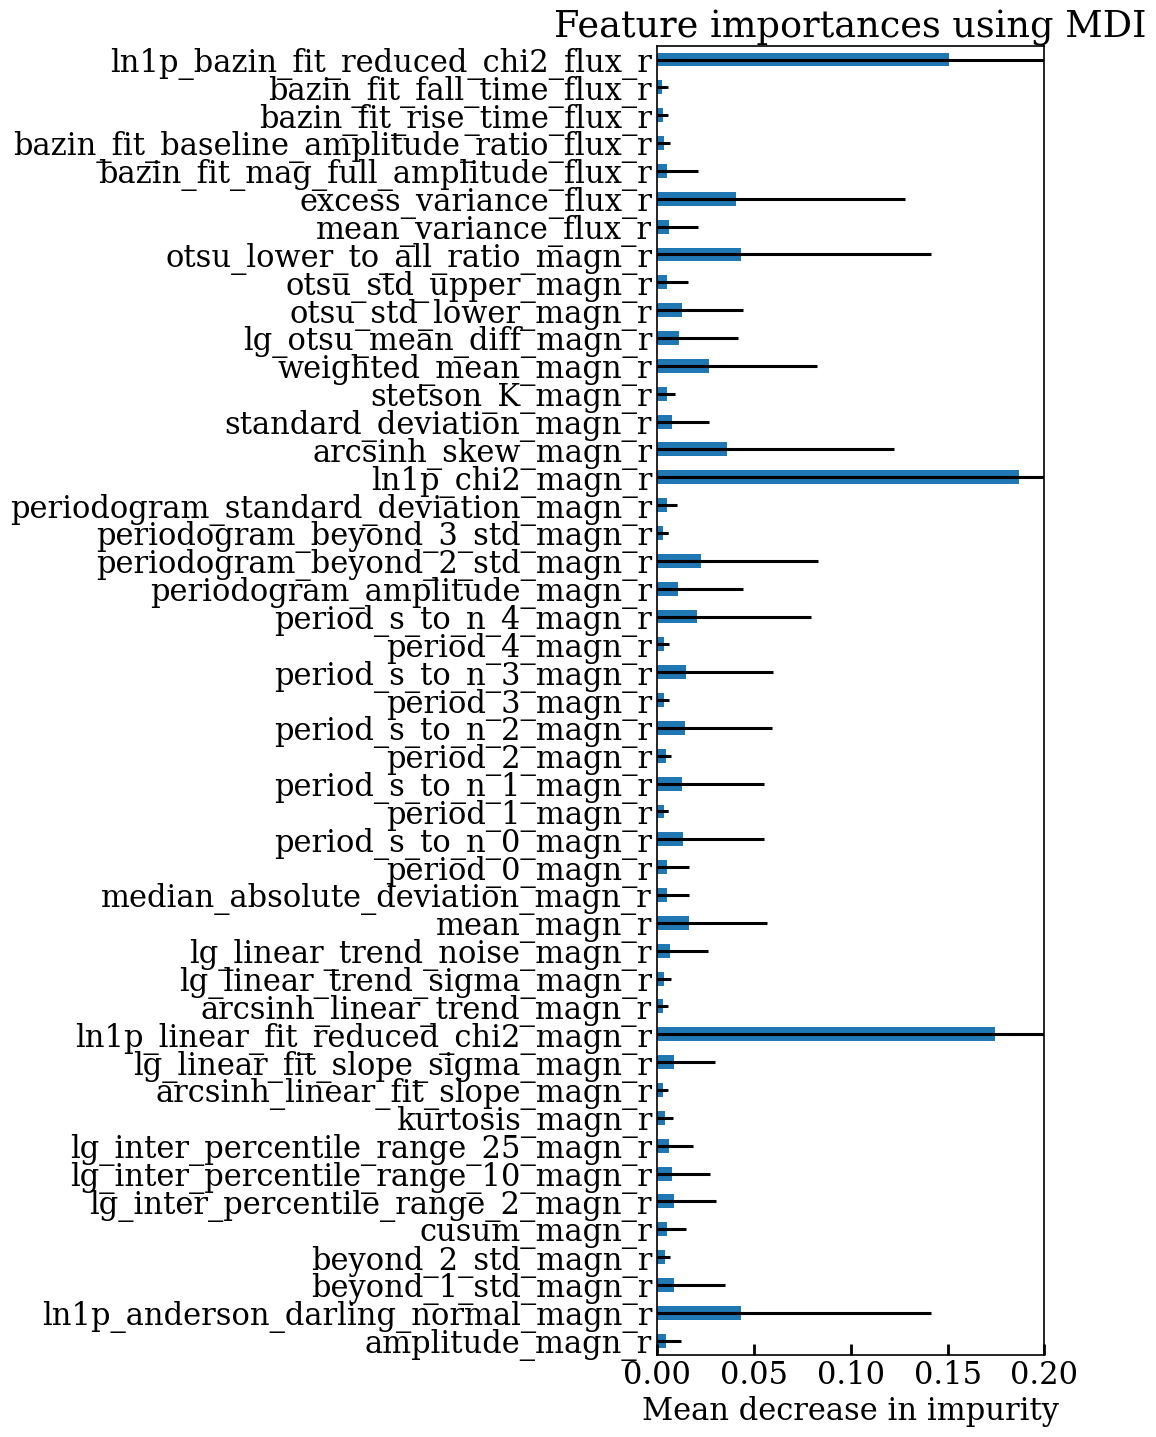

In [20]:
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=names)

# fig, ax = plt.subplots(figsize=(15,5))
# forest_importances.plot.bar(yerr=std, ax=ax)
# ax.set_title("Feature importances using MDI")
# ax.set_ylabel("Mean decrease in impurity")
# plt.ylim(0, 0.2)
#fig.tight_layout()


fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

plt.savefig('feature_imp.png', bbox_inches='tight')

In [21]:
filtered = np.array([False if 'chi2' in str(item) else True for item in names])

In [22]:
# Train and validate real-bogus model
print('Training model...')
t = time.monotonic()
model = RandomForestClassifier(max_depth=18, n_estimators=831, random_state=random_seed)
score_types = ('accuracy', 'roc_auc', 'f1')

result = cross_validate(model, train_data[:, filtered], train_labels,
                        cv=KFold(shuffle=True, random_state=random_seed),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                        n_jobs=5
                       )

print('Scores for Random Forest Classifier:')
for score in score_types:
    mean = np.mean(result[f'test_{score}'])
    std = np.std(result[f'test_{score}'])
    print(f'{score} = {mean:.3f} +- {std:.3f}')
t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')
    
#assert np.mean(result['test_accuracy']) > 0.7, 'Accuracy for trained model is too low!'
clf = result['estimator'][0]

#convert_to_onnx(clf, len(names), name=model_name)

Training model...
Scores for Random Forest Classifier:
accuracy = 0.947 +- 0.006
roc_auc = 0.986 +- 0.003
f1 = 0.947 +- 0.005
RF trained (with cross-validation) in 0 m


In [23]:
test_pred = clf.predict_proba(test_data[:, filtered])
akb_roc_auc = metrics.roc_auc_score(test_labels, test_pred[:, 1])
akb_accuracy = clf.score(test_data[:, filtered], test_labels)
print('Results on test data (SN from akb):')
print(f'ROC-AUC = {akb_roc_auc:.3f}')
print(f'Accuracy = {akb_accuracy:.3f}')

Results on test data (SN from akb):
ROC-AUC = 0.996
Accuracy = 0.962


/tmp/ipykernel_1643/2806668747.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


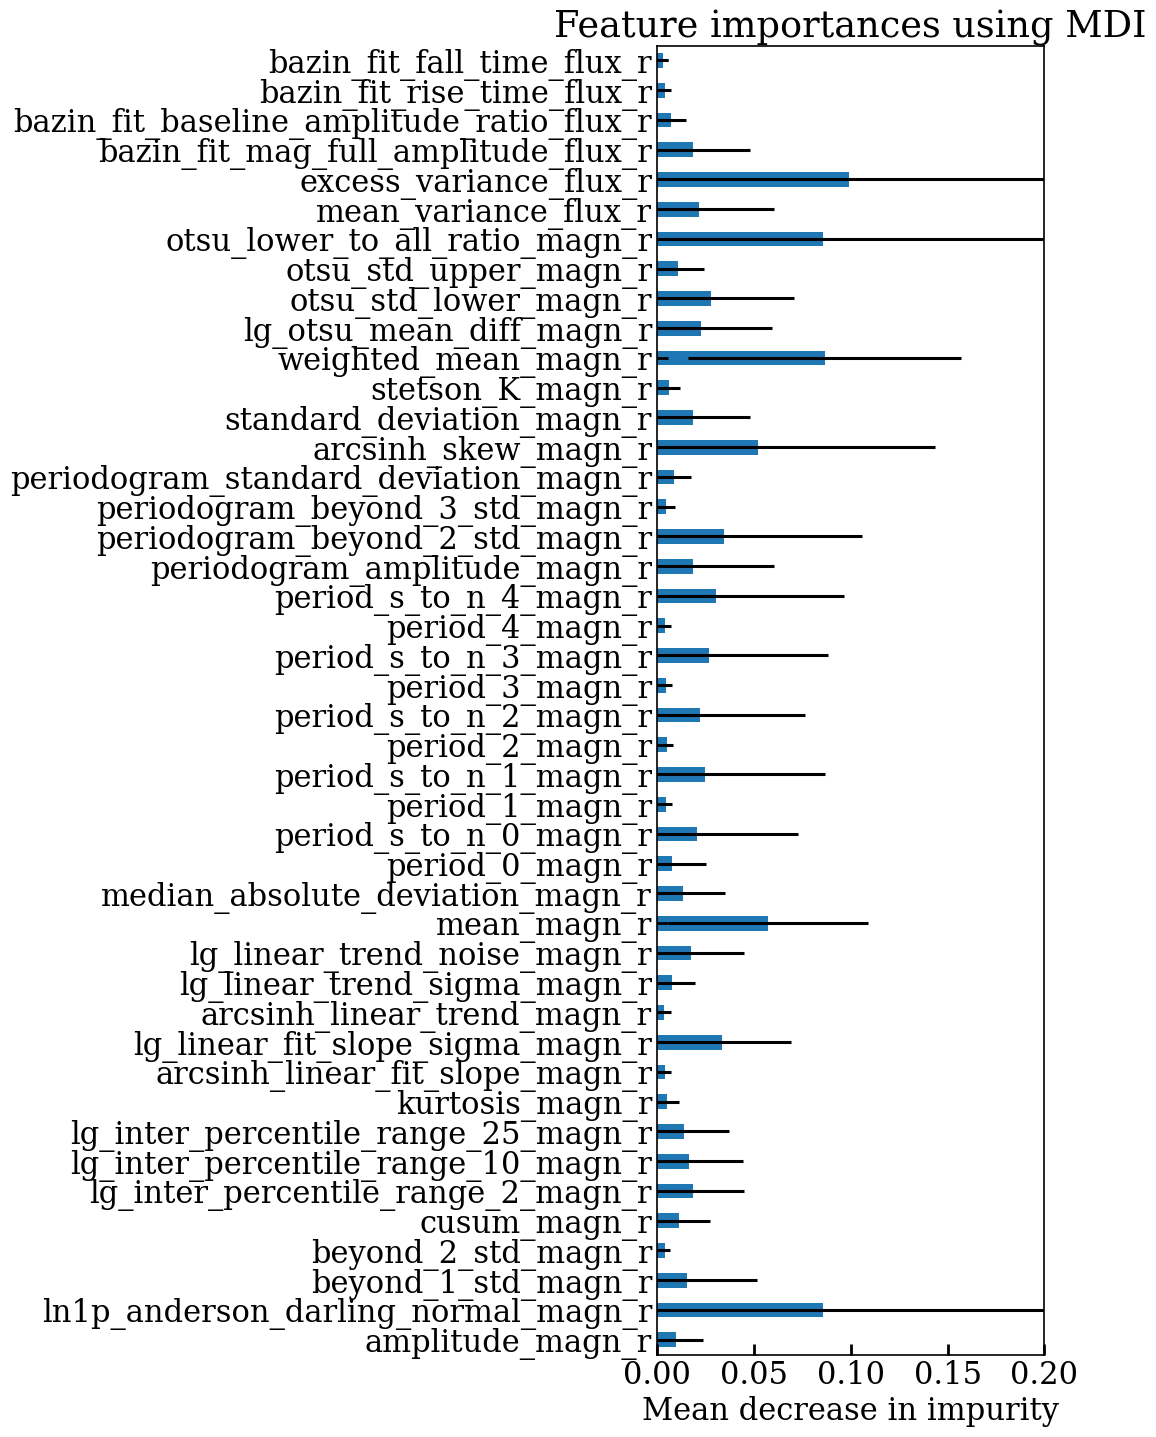

In [24]:
# importances = clf.feature_importances_
# std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

# forest_importances = pd.Series(importances, index=np.array(names)[filtered])

# fig, ax = plt.subplots(figsize=(17,5))
# forest_importances.plot.bar(yerr=std, ax=ax)
# ax.set_title("Feature importances using MDI")
# ax.set_ylabel("Mean decrease in impurity")
# plt.ylim(0, 0.2)
# fig.tight_layout()

importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=np.array(names)[filtered])

fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

plt.savefig('feature_imp_no-chi2.png', bbox_inches='tight')

(array([1717.,  381.,  208.,  121.,   85.,   50.,   53.,   31.,   18.,
          24.,   13.,   11.,    6.,    6.,    5.,    6.,    6.,    7.,
          19.,   14.,   27.,   22.,   34.,   34.,   54.,   61.,   72.,
         161.,  329., 1851.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

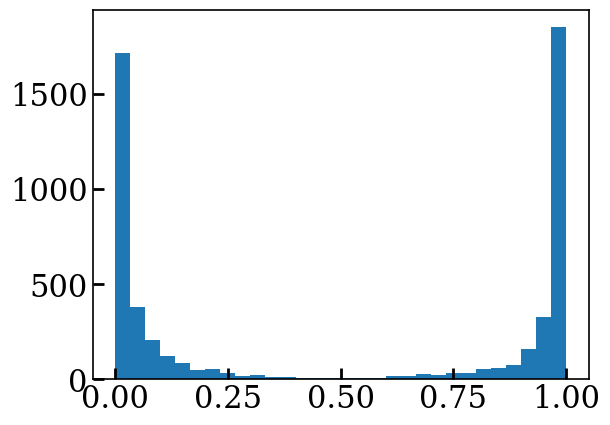

In [33]:
train_pred = clf.predict_proba(train_data[:, filtered])[:, 1]
plt.hist(train_pred, bins=30)